In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE


In [25]:
data_path = Path('data/E_Commerce_Cleaned.csv')
df = pd.read_csv(data_path)

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 35 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   CustomerID                              5630 non-null   int64  
 1   Churn                                   5630 non-null   int64  
 2   Tenure                                  5630 non-null   float64
 3   CityTier                                5630 non-null   int64  
 4   WarehouseToHome                         5630 non-null   float64
 5   HourSpendOnApp                          5630 non-null   float64
 6   NumberOfDeviceRegistered                5630 non-null   int64  
 7   SatisfactionScore                       5630 non-null   int64  
 8   NumberOfAddress                         5630 non-null   int64  
 9   Complain                                5630 non-null   int64  
 10  OrderAmountHikeFromlastYear             5630 non-null   float64
 11  Co

In [46]:
df.sample(5)

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,...,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Others,PreferedOrderCat_Phone,MaritalStatus_Married,MaritalStatus_Single
5277,55278,0,8.0,1,8.0,3.0,4,1,11,0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3278,53279,0,24.0,1,9.0,4.0,4,3,7,0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3355,53356,0,21.0,3,9.0,4.0,5,2,3,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1148,51149,1,0.0,1,14.0,3.0,3,5,2,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4608,54609,0,14.0,1,13.0,4.0,4,3,9,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


Text(0.5, 1.0, 'Original Class Distribution')

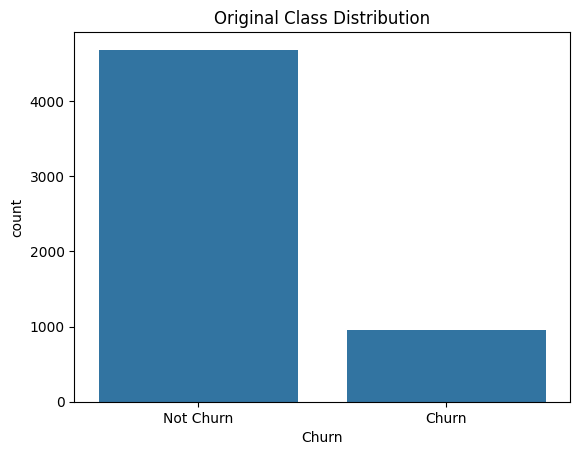

In [64]:
sns.countplot(data=df, x='Churn')
plt.xticks([0, 1], ['Not Churn', 'Churn'])
plt.title('Original Class Distribution')

In [48]:
X = df.drop(columns=['CustomerID','Churn'])  
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
smote=SMOTE(sampling_strategy='minority',random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

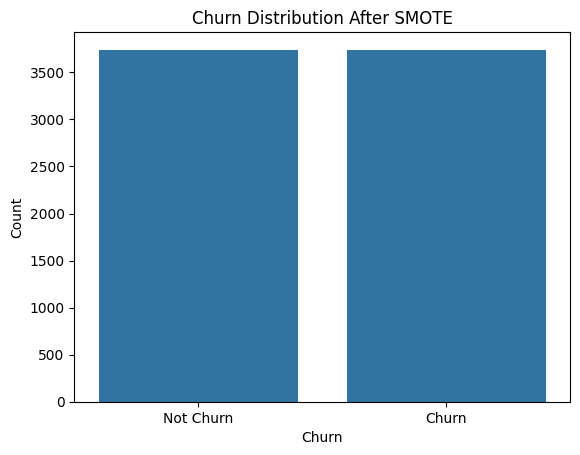

In [59]:
counts_sm = y_train_sm.value_counts()
sns.barplot(x=counts_sm.index, y=counts_sm.values)
plt.xticks([0,1],['Not Churn', 'Churn'])
plt.ylabel("Count")
plt.xlabel('Churn')
plt.title("Churn Distribution After SMOTE")
plt.show()